<a href="https://colab.research.google.com/github/MohitKhetan10/flower-classifier/blob/main/WEEK4_vgg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import os

# Upload files manually from your computer
uploaded = files.upload()

# Create a folder to store them
os.makedirs("/content/images", exist_ok=True)

# Move uploaded files into the folder
for fname in uploaded.keys():
    os.rename(fname, f"/content/images/{fname}")

print("Uploaded files:", os.listdir("/content/images"))


Saving cafe.jpg to cafe.jpg
Saving headphone.jpg to headphone.jpg
Saving hydrant.jpg to hydrant.jpg
Saving koala.jpg to koala.jpg
Saving pier.jpg to pier.jpg
Saving rose.jpeg to rose.jpeg
Saving scene.jpg to scene.jpg
Saving tiger.jpg to tiger.jpg
Uploaded files: ['rose.jpeg', 'pier.jpg', 'tiger.jpg', 'hydrant.jpg', 'cafe.jpg', 'headphone.jpg', 'koala.jpg', 'scene.jpg']


In [2]:
import os, shutil

base_dir = "/content/images"
files = os.listdir(base_dir)

for f in files:
    name, ext = os.path.splitext(f)
    class_dir = os.path.join(base_dir, name)
    os.makedirs(class_dir, exist_ok=True)
    shutil.move(os.path.join(base_dir, f), os.path.join(class_dir, f))

print("Organized structure:", os.listdir(base_dir))


Organized structure: ['tiger', 'scene', 'pier', 'rose', 'cafe', 'hydrant', 'koala', 'headphone']


In [4]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

BATCH_SIZE = 8
IMG_SIZE = (224, 224)
data_dir = "/content/images"

# Load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Capture class names before mapping
class_names = train_dataset.class_names
print("Detected classes:", class_names)

# Preprocess for VGG16
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

# Build VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

# Evaluate
loss, acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.2f}")


Found 8 files belonging to 8 classes.
Using 7 files for training.
Found 8 files belonging to 8 classes.
Using 1 files for validation.
Detected classes: ['cafe', 'headphone', 'hydrant', 'koala', 'pier', 'rose', 'scene', 'tiger']
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.1429 - loss: 7.4569 - val_accuracy: 0.0000e+00 - val_loss: 8.0992
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7143 - loss: 0.7840 - val_accuracy: 0.0000e+00 - val_loss: 10.8293
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.0000e+00 - val_loss: 12.9272
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.0000e+00 - val_loss: 14.5081
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.0000e+00 - val_loss: 15.8397
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0000e+00 - loss: 15.8397
Validation Accuracy: 0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step


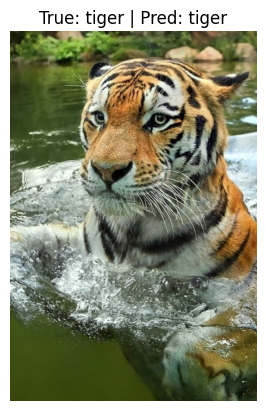

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


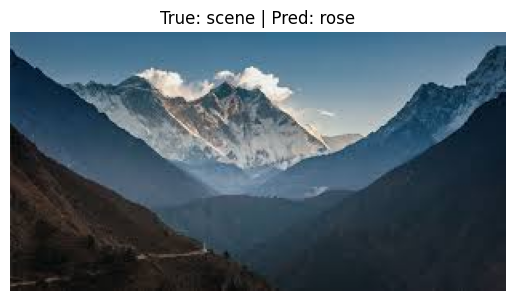

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


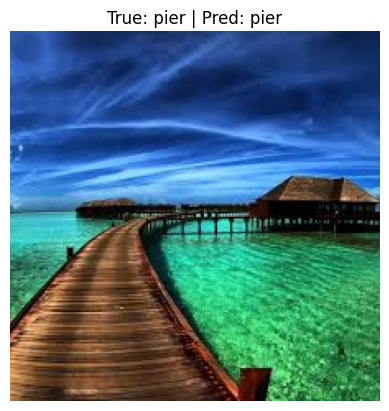

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


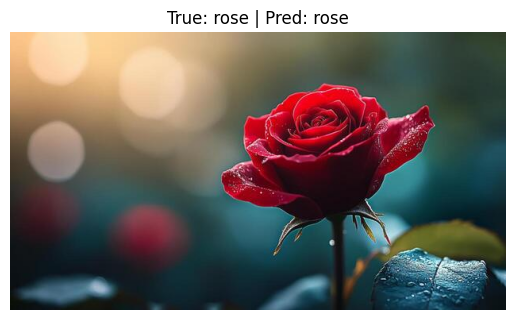

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


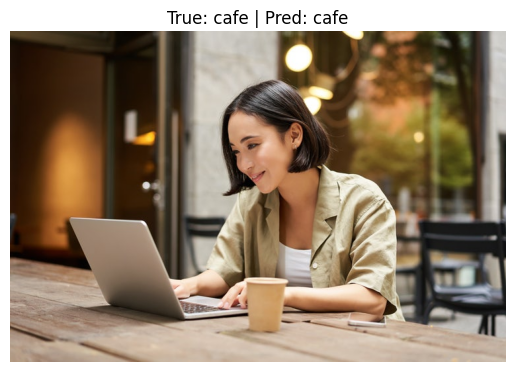

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


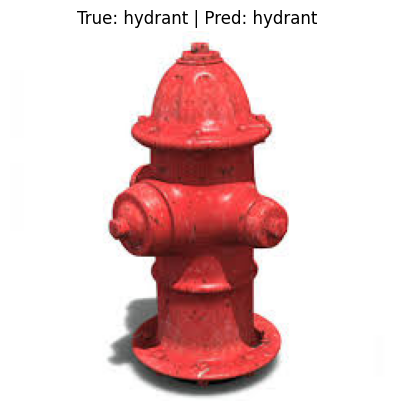

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


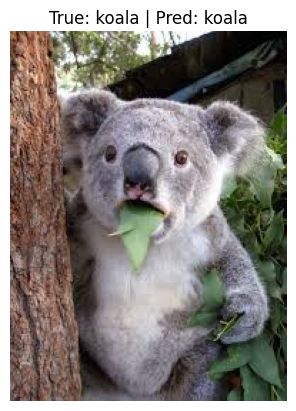

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


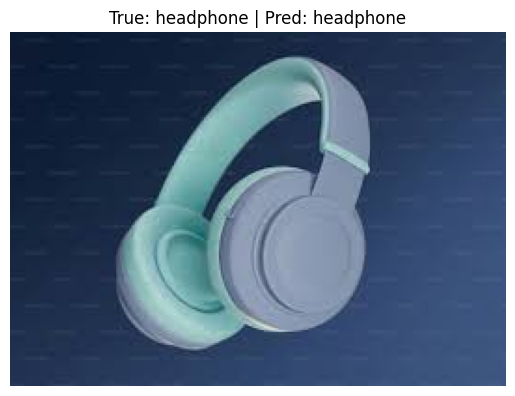

In [6]:
from tensorflow.keras.preprocessing import image   # <-- add this import
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

# Collect all image paths (now inside subfolders)
image_paths = glob.glob("/content/images/*/*")

for img_path in image_paths:
    # Load and preprocess
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(np.expand_dims(img_array, axis=0))

    # Predict
    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    # Show image with true vs predicted label
    plt.imshow(image.load_img(img_path))
    plt.title(f"True: {os.path.basename(os.path.dirname(img_path))} | Pred: {predicted_class}")
    plt.axis("off")
    plt.show()


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Collect true labels and predictions
true_labels = []
pred_labels = []

for img_path in image_paths:
    # True label = folder name
    true_class = os.path.basename(os.path.dirname(img_path))
    true_labels.append(true_class)

    # Predict
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(np.expand_dims(img_array, axis=0))

    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]
    pred_labels.append(predicted_class)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=class_names)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n", classification_report(true_labels, pred_labels, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Confusion Matrix:
 [[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]]

Classification Report:
               precision    recall  f1-score   support

        cafe       1.00      1.00      1.00         1
   headphone       1.00      1.00      1.00         1
     hydrant       1.00      1.00      1.00         1
       koala       1.00      1.00      1.00         1
        pier       1.00      1.00      1.00         1
        rose       0.50      1.00      0.67         1
       scene       0.00      0.00      0.00         1
       tiger       1.00      1.00      1.00         1

    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import kagglehub
import os

# Download the dataset directly from Kaggle
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

print(f"Dataset downloaded to: {path}\n")


Using Colab cache for faster access to the 'ai-vs-real-images-dataset' dataset.
Dataset downloaded to: /kaggle/input/ai-vs-real-images-dataset



In [2]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Load dataset from Kagglehub path
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Detected classes:", class_names)

# Preprocess
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

# VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_dataset, validation_data=val_dataset, epochs=5)

# Evaluate
loss, acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.2f}")


Found 995 files belonging to 2 classes.
Using 796 files for training.
Found 995 files belonging to 2 classes.
Using 199 files for validation.
Detected classes: ['Ai_generated_dataset', 'real_dataset']
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8229 - loss: 1.0769 - val_accuracy: 0.9196 - val_loss: 0.2353
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 540ms/step - accuracy: 0.9711 - loss: 0.1001 - val_accuracy: 0.9246 - val_loss: 0.3080
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 530ms/step - accuracy: 0.9837 - loss: 0.0400 - val_accuracy: 0.9397 - val_loss: 0.2304
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step - accuracy: 0.9975 - loss: 0.0101 - val_accuracy: 0.9447 - val_loss: 0.1869
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9648 - val_loss: 0.1730
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 697ms/step - accuracy: 0.9648 - loss: 0.1730
Validation Accuracy: 0.96


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step


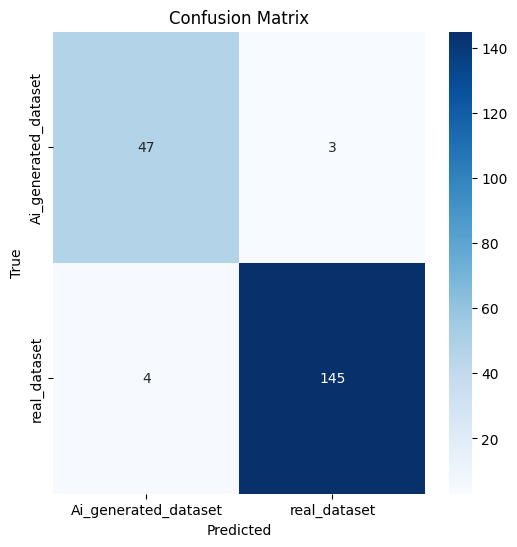


Classification Report:

                      precision    recall  f1-score   support

Ai_generated_dataset       0.92      0.94      0.93        50
        real_dataset       0.98      0.97      0.98       149

            accuracy                           0.96       199
           macro avg       0.95      0.96      0.95       199
        weighted avg       0.97      0.96      0.96       199



In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Collect true labels and predictions
true_labels = []
pred_labels = []

# Iterate through validation dataset
for batch_images, batch_labels in val_dataset:
    preds = model.predict(batch_images)
    pred_classes = np.argmax(preds, axis=1)
    true_labels.extend(batch_labels.numpy())
    pred_labels.extend(pred_classes)

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [7]:
import kagglehub
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os

# ==========================================
# PART 1: THE INCEPTION IMPORTS
# ==========================================
# Import the InceptionV3 model and its specific preprocess function
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# ==========================================
# PART 2: DATA PREPARATION (PROVIDED)
# ==========================================
path = kagglehub.dataset_download("pavansanagapati/images-dataset")
data_dir = os.path.join(path, "data", "data")
if not os.path.exists(data_dir):
    data_dir = path

# InceptionV3 requires 299x299 input resolution
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Apply Inception's specific preprocessing math
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

# ==========================================
# PART 3: BUILD THE TRANSFER LEARNING MODEL
# ==========================================

# Load the InceptionV3 base model (exclude top, use ImageNet weights)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze the base model
base_model.trainable = False

# Build the custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Final Dense classification layer for 7 classes
predictions = Dense(7, activation='softmax')(x)

# Stitch it together and compile
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Model Ready for Training ---")
model.summary()

print("\n--- Starting Training ---")
history = model.fit(train_dataset, validation_data=val_dataset, epochs=5)


Using Colab cache for faster access to the 'images-dataset' dataset.
Found 1803 files belonging to 7 classes.
Using 1443 files for training.
Found 1803 files belonging to 7 classes.
Using 360 files for validation.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Model Ready for Training ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,817,127 (83.23 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 21,802,784 (83.17 MB)


--- Starting Training ---
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 52s 724ms/step - accuracy: 0.8261 - loss: 0.6535 - val_accuracy: 0.9639 - val_loss: 0.1991
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.9854 - loss: 0.1137 - val_accuracy: 0.9722 - val_loss: 0.1235
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.9896 - loss: 0.0712 - val_accuracy: 0.9778 - val_loss: 0.0978
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9951 - loss: 0.0495 - val_accuracy: 0.9778 - val_loss: 0.0881
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.9958 - loss: 0.0388 - val_accuracy: 0.9833 - val_loss: 0.0779


In [8]:
import kagglehub
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os

# ==========================================
# PART 1: THE INCEPTION IMPORTS
# ==========================================
# Import the InceptionV3 model and its specific preprocess function
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# ==========================================
# PART 2: DATA PREPARATION (PROVIDED)
# ==========================================
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

data_dir = os.path.join(path, "data", "data")
if not os.path.exists(data_dir):
    data_dir = path

# InceptionV3 requires 299x299 input resolution
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# Apply Inception's specific preprocessing math
train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

# ==========================================
# PART 3: BUILD THE TRANSFER LEARNING MODEL
# ==========================================

# Load the InceptionV3 base model (exclude top, use ImageNet weights)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze the base model
base_model.trainable = False

# Build the custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Final Dense classification layer for 7 classes
predictions = Dense(7, activation='softmax')(x)

# Stitch it together and compile
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Model Ready for Training ---")
model.summary()

print("\n--- Starting Training ---")
history = model.fit(train_dataset, validation_data=val_dataset, epochs=5)


Using Colab cache for faster access to the 'ai-vs-real-images-dataset' dataset.
Found 995 files belonging to 2 classes.
Using 796 files for training.
Found 995 files belonging to 2 classes.
Using 199 files for validation.

--- Model Ready for Training ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,817,127 (83.23 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 21,802,784 (83.17 MB)


--- Starting Training ---
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6709 - loss: 0.7455 - val_accuracy: 0.8191 - val_loss: 0.4407
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 519ms/step - accuracy: 0.8543 - loss: 0.3598 - val_accuracy: 0.8744 - val_loss: 0.3254
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 516ms/step - accuracy: 0.8932 - loss: 0.2864 - val_accuracy: 0.8844 - val_loss: 0.2691
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 509ms/step - accuracy: 0.9171 - loss: 0.2270 - val_accuracy: 0.9146 - val_loss: 0.2285
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 500ms/step - accuracy: 0.9372 - loss: 0.1967 - val_accuracy: 0.9196 - val_loss: 0.2067


In [9]:
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# Download MNIST dataset from Kaggle
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print("Dataset downloaded to:", path)

# Load MNIST from TensorFlow directly (simpler than parsing CSVs)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess: reshape to (28,28,1), normalize to [0,1]
x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255.0


Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Dataset downloaded to: /kaggle/input/mnist-in-csv
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
def inception_module(x, filters):
    # filters = [f1, f3r, f3, f5r, f5, pool_proj]
    f1, f3r, f3, f5r, f5, pool_proj = filters

    path1 = layers.Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    path2 = layers.Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    path2 = layers.Conv2D(f3, (3,3), padding='same', activation='relu')(path2)

    path3 = layers.Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    path3 = layers.Conv2D(f5, (5,5), padding='same', activation='relu')(path3)

    path4 = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = layers.Conv2D(pool_proj, (1,1), padding='same', activation='relu')(path4)

    return layers.concatenate([path1, path2, path3, path4], axis=-1)


In [11]:
inputs = layers.Input(shape=(28,28,1))

# Initial conv + pool
x = layers.Conv2D(64, (7,7), strides=(2,2), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

# Inception modules
x = inception_module(x, [64,96,128,16,32,32])
x = inception_module(x, [128,128,192,32,96,64])
x = layers.MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

x = inception_module(x, [192,96,208,16,48,64])
x = inception_module(x, [160,112,224,24,64,64])
x = inception_module(x, [128,128,256,24,64,64])
x = inception_module(x, [112,144,288,32,64,64])
x = inception_module(x, [256,160,320,32,128,128])
x = layers.MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

x = inception_module(x, [256,160,320,32,128,128])
x = inception_module(x, [384,192,384,48,128,128])

# Global average pooling + dense
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation='softmax')(x)  # MNIST has 10 classes

model = models.Model(inputs, outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 14, 14,    │      3,200 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 7, 7, 64)  │          0 │ conv2d_188[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 7, 7, 96)  │      6,240 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 7, 7, 16)  │      1,040 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 7, 7, 64)  │          0 │ max_pooling2d_8[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 7, 7, 64)  │      4,160 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 7, 7, 128) │    110,720 │ conv2d_190[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_193 (Conv2D) │ (None, 7, 7, 32)  │     12,832 │ conv2d_192[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_194 (Conv2D) │ (None, 7, 7, 32)  │      2,080 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 7, 7, 256) │          0 │ conv2d_189[0][0], │
│ (Concatenate)       │                   │            │ conv2d_191[0][0], │
│                     │                   │            │ conv2d_193[0][0], │
│                     │                   │            │ conv2d_194[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_196 (Conv2D) │ (None, 7, 7, 128) │     32,896 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_198 (Conv2D) │ (None, 7, 7, 32)  │      8,224 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 7, 7, 256) │          0 │ concatenate_4[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_195 (Conv2D) │ (None, 7, 7, 128) │     32,896 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_197 (Conv2D) │ (None, 7, 7, 192) │    221,376 │ conv2d_196[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_199 (Conv2D) │ (None, 7, 7, 96)  │     76,896 │ conv2d_198[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_200 (Conv2D) │ (None, 7, 7, 64)  │     16,448 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 7, 7, 480) │          0 │ conv2d_195[0][0], │
│ (Concatenate)       │                   │            │ conv2d_197[0][0], │
│                     │                   │            │ conv2d_199[0][0], │
│                     │                   │            │ conv2d_200[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,835,962 (22.26 MB)

 Trainable params: 5,835,962 (22.26 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(x_train, y_train, epochs=5, batch_size=128,
                    validation_data=(x_test, y_test))

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 103ms/step - accuracy: 0.6362 - loss: 0.9236 - val_accuracy: 0.9649 - val_loss: 0.1160
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9740 - loss: 0.0902 - val_accuracy: 0.9859 - val_loss: 0.0471
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9830 - loss: 0.0585 - val_accuracy: 0.9878 - val_loss: 0.0454
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9855 - loss: 0.0513 - val_accuracy: 0.9835 - val_loss: 0.0564
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9835 - val_loss: 0.0611
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9835 - loss: 0.0611
Test Accuracy: 0.98


In [1]:
import tensorflow as tf
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

# Load Flowers dataset from TFDS
import tensorflow_datasets as tfds
(train_ds, val_ds), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Preprocess pipeline
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)  # VGG19 preprocessing
    return image, label

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Base model
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(ds_info.features["label"].num_classes, activation="softmax")(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("\n--- Training VGG19 on Flowers ---")
history = model.fit(train_ds, validation_data=val_ds, epochs=5)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.PBCQAC_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

--- Training VGG19 on Flowers ---
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2896s 32s/step - accuracy: 0.5419 - loss: 2.0368 - val_accuracy: 0.7139 - val_loss: 1.0565
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2806s 31s/step - accuracy: 0.7752 - loss: 0.7569 - val_accuracy: 0.7834 - val_loss: 0.7156
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2836s 30s/step - accuracy: 0.8300 - loss: 0.5148 - val_accuracy: 0.8243 - val_loss: 0.5921
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2782s 30s/step - accuracy: 0.8658 - loss: 0.3937 - val_accuracy: 0.8297 - val_loss: 0.5356
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2778s 30s/step - accuracy: 0.8886 - loss: 0.3197 - val_accuracy: 0.8460 - val_loss: 0.5019


In [7]:
model.save("flowers_vgg19.keras")


In [9]:
from tensorflow.keras.models import load_model

model = load_model("flowers_vgg19.keras")

# Recompile with a fresh optimizer
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


In [10]:
from tensorflow.keras.models import load_model

model = load_model("flowers_vgg19.keras")


In [11]:
!ls -lh


total 154M
-rw-r--r-- 1 root root  77M Apr  3 14:15 flowers_vgg19.h5
-rw-r--r-- 1 root root  77M Apr  3 14:17 flowers_vgg19.keras
drwxr-xr-x 1 root root 4.0K Mar 30 13:29 sample_data


In [12]:
from google.colab import files
files.download("flowers_vgg19.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>